In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [55]:
drl_data = pd.read_csv(
    "data/data_2019-01-01_2024-01-01_hourly.csv",
    parse_dates=["time"],
    index_col="time",
)
drl_data.index = pd.to_datetime(drl_data.index, utc=True)

In [56]:
drl_data.drop(
    columns=["exaa_15min_de_lu_eur_per_mwh"], inplace=True
)
exaa_data = pd.read_csv(
    "data/exaa_h_prices/exaa_60min_prices_2019_2025_utc.csv", parse_dates=['timestamp_utc'],
    index_col='timestamp_utc'
)
exaa_data.index = pd.to_datetime(exaa_data.index, utc=True)
exaa_data = exaa_data.rename(columns={'GREY_DE_price': 'exaa_15min_de_lu_eur_per_mwh'})
exaa_data = exaa_data["exaa_15min_de_lu_eur_per_mwh"]

drl_data = drl_data.join(exaa_data, how='left')

In [57]:
ri_profit1 = pd.read_csv("output/single_market/rolling_intrinsic/ri_basic/qh/2019/bs15cr1rto0.86mc365mt10/profit.csv")
ri_profit2 = pd.read_csv("output/single_market/rolling_intrinsic/ri_basic/qh/2023/bs15cr1rto0.86mc365mt10/profit.csv")

ri_profit = pd.concat([ri_profit1, ri_profit2], ignore_index=True)
ri_profit = ri_profit.set_index("day")  # aktuell: dtype=object mit +01:00 im String


In [58]:
# 1) Index-Strings auf 'YYYY-MM-DD HH:MM:SS' kürzen (Offset abschneiden)
idx = ri_profit.index.astype(str).str.slice(0, 19)
# z.B. '2019-01-01 00:00:00+01:00' -> '2019-01-01 00:00:00'

# 2) In echte Datumswerte umwandeln (noch ohne Zeitzone)
idx = pd.to_datetime(idx)  # dtype: datetime64[ns], immer 00:00:00

# 3) Zeitzone als UTC hinzufügen
idx = idx.tz_localize("UTC")  # dtype: datetime64[ns, UTC]

# 4) Zurück als Index setzen
ri_profit.index = idx

# Optional: Index-Name an den anderen DF anpassen
ri_profit.index.name = "date"

In [59]:
drl_data.drop(columns=["id_full_qh"], inplace=True)

In [ ]:
# --- 2) Residual Load berechnen ---

drl_data["residual_load"] = (
    drl_data["load_forecast_d_minus_1_1000_total_de_lu_mw"]
    - drl_data["pv_forecast_d_minus_1_1000_de_lu_mw"]
    - drl_data["wind_offshore_forecast_d_minus_1_1000_de_lu_mw"]
    - drl_data["wind_onshore_forecast_d_minus_1_1000_de_lu_mw"]
)



agg_features = [
    "epex_spot_60min_de_lu_eur_per_mwh",
    "exaa_15min_de_lu_eur_per_mwh",
    "load_forecast_d_minus_1_1000_total_de_lu_mw",
    "pv_forecast_d_minus_1_1000_de_lu_mw",
    "wind_offshore_forecast_d_minus_1_1000_de_lu_mw",
    "wind_onshore_forecast_d_minus_1_1000_de_lu_mw",
    "residual_load",
    "id_full_h",
   # "id_full_qh",
]

agg_dict = {
    col: [
        "mean",
        "std",
        "min",
        "max",
    ]
    for col in agg_features
}

daily_agg = (
    drl_data
    .resample("D")      # täglich auf Index 'time'
    .agg(agg_dict)
)

daily_agg.columns = [
    f"{col}_{stat}" for col, stat in daily_agg.columns.to_flat_index()
]
daily_agg.index.name = "date"

daily_agg["epex_spread"] = (
    daily_agg["epex_spot_60min_de_lu_eur_per_mwh_max"]
    - daily_agg["epex_spot_60min_de_lu_eur_per_mwh_min"]
)

daily_agg["exaa_15min_spread"] = (
    daily_agg["exaa_15min_de_lu_eur_per_mwh_max"]
    - daily_agg["exaa_15min_de_lu_eur_per_mwh_min"]
)

daily_agg["residual_load_spread"] = (
    daily_agg["residual_load_max"] - daily_agg["residual_load_min"]
)

daily_agg["id_full_h_spread"] = (
    daily_agg["id_full_h_max"] - daily_agg["id_full_h_min"]
)

daily_agg["day_of_week"] = daily_agg.index.dayofweek
daily_agg["month"] = daily_agg.index.month
daily_agg["year"] = daily_agg.index.year





def add_daily_delta_features(
    df,
    column,
    prefix=None,
):
    """
    Berechnet für eine Zeitreihe:
    - tägliche Summe der absoluten Deltas
    - maximale Intraday-Rampe
    """
    if prefix is None:
        prefix = column

    delta = (
        df[column]
        .groupby(df.index.date)
        .diff()
        .abs()
    )

    daily = pd.DataFrame({
        f"{prefix}_delta_sum": delta.resample("D").sum(),
        f"{prefix}_delta_max": delta.resample("D").max(),
    })

    return daily




delta_features = []

delta_features.append(
    add_daily_delta_features(
        drl_data,
        "epex_spot_60min_de_lu_eur_per_mwh",
        prefix="epex_spot"
    )
)

delta_features.append(
    add_daily_delta_features(
        drl_data,
        "exaa_15min_de_lu_eur_per_mwh",
        prefix="exaa_15min"
    )
)

delta_features.append(
    add_daily_delta_features(
        drl_data,
        "pv_forecast_d_minus_1_1000_de_lu_mw",
        prefix="pv"
    )
)

delta_features.append(
    add_daily_delta_features(
        drl_data,
        "wind_onshore_forecast_d_minus_1_1000_de_lu_mw",
        prefix="wind_onshore"
    )
)

delta_features.append(
    add_daily_delta_features(
        drl_data,
        "wind_offshore_forecast_d_minus_1_1000_de_lu_mw",
        prefix="wind_offshore"
    )
)

delta_features.append(
    add_daily_delta_features(
        drl_data,
        "residual_load",
        prefix="residual_load"
    )
)

daily_delta_all = pd.concat(delta_features, axis=1)

daily_agg = daily_agg.join(daily_delta_all)


In [65]:

df_daily = daily_agg.join(ri_profit[["profit", "cycles"]], how="inner")

print(df_daily.shape)

df_daily

(1826, 53)


,epex_spot_60min_de_lu_eur_per_mwh_mean,epex_spot_60min_de_lu_eur_per_mwh_std,epex_spot_60min_de_lu_eur_per_mwh_min,epex_spot_60min_de_lu_eur_per_mwh_max,exaa_15min_de_lu_eur_per_mwh_mean,exaa_15min_de_lu_eur_per_mwh_std,exaa_15min_de_lu_eur_per_mwh_min,exaa_15min_de_lu_eur_per_mwh_max,load_forecast_d_minus_1_1000_total_de_lu_mw_mean,load_forecast_d_minus_1_1000_total_de_lu_mw_std,...,pv_delta_sum,pv_delta_max,wind_onshore_delta_sum,wind_onshore_delta_max,wind_offshore_delta_sum,wind_offshore_delta_max,residual_load_delta_sum,residual_load_delta_max,profit,cycles
date,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,-6.875833,10.786639,-33.57,10.07,-4.878333,10.214174,-20.00,13.54,47744.070208,5133.243773,...,4424.875,816.7325,18310.9550,1729.1225,1606.9900,305.5500,35396.5875,2886.1950,68.233139,1.0
2019-01-02 00:00:00+00:00,29.104167,40.083914,-48.93,62.11,39.668333,25.494614,-8.60,70.08,55944.564583,8385.547397,...,12974.745,2434.9175,22856.7100,2629.0125,2609.7275,435.5225,54600.7200,7504.9525,159.440419,2.0
2019-01-03 00:00:00+00:00,58.042083,9.148248,43.88,69.55,58.426250,8.761658,43.99,70.66,57691.780937,7265.181910,...,9828.700,1981.1900,7867.1500,855.9500,2637.3275,343.0850,42801.0300,5740.5400,56.598649,3.0
2019-01-04 00:00:00+00:00,48.917083,7.091700,26.90,55.78,48.908750,7.325688,30.18,59.77,55457.005625,6982.070073,...,3848.575,761.7675,16783.4850,1640.1500,3283.8425,634.4625,42034.4275,4489.0700,64.915423,4.0
2019-01-05 00:00:00+00:00,43.155417,14.022366,18.37,61.64,41.821250,14.584779,13.81,60.72,52843.881458,5805.721892,...,2741.525,504.0975,21259.6300,1494.2750,2362.4750,598.5150,42542.5050,6471.1975,102.020127,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27 00:00:00+00:00,59.074583,24.869555,-0.02,82.73,59.482500,23.444031,1.89,89.00,53093.031354,7597.601289,...,19529.535,3543.5275,38360.0575,3935.0325,7738.5300,1334.7100,72683.9650,6577.7275,106.523683,88.0
2023-12-28 00:00:00+00:00,16.670833,16.803733,-1.43,46.83,23.866250,20.339894,-5.05,64.08,55965.022708,7561.289589,...,15637.880,2820.3225,8205.3500,1143.6550,3266.9675,1130.9175,48287.1025,4767.0525,102.341338,89.0
2023-12-29 00:00:00+00:00,6.605000,8.989161,-0.95,26.59,7.230417,12.487037,-8.45,34.49,54341.245000,6885.347145,...,14551.115,2645.3100,11782.7250,1871.0975,2912.4800,1356.5150,43090.8850,4559.2200,91.073262,90.0


In [66]:
# --- 4) Features + Target zusammenführen ---

# Annahme: ri_daily hat Spalten 'profit' und 'cycles'
ri_profit.index.name = "date"
df_daily = daily_agg.merge(
    ri_profit[["profit", "cycles"]],
    left_index=True,
    right_index=True,
    how="inner"
)

In [67]:
"""

test_columns = ["profit", "exaa_spread", "exaa_15min_de_lu_eur_per_mwh_std",
                 "exaa_15min_delta_sum", "exaa_15min_delta_max",
                   "exaa_15min_de_lu_eur_per_mwh_max" ,"exaa_15min_de_lu_eur_per_mwh_min",
                     "exaa_15min_de_lu_eur_per_mwh_mean", "epex_spot_60min_de_lu_eur_per_mwh_mean"]
df_daily = df_daily[test_columns].copy()
df_daily

"""

'\n\ntest_columns = ["profit", "exaa_spread", "exaa_15min_de_lu_eur_per_mwh_std",\n                 "exaa_15min_delta_sum", "exaa_15min_delta_max",\n                   "exaa_15min_de_lu_eur_per_mwh_max" ,"exaa_15min_de_lu_eur_per_mwh_min",\n                     "exaa_15min_de_lu_eur_per_mwh_mean", "epex_spot_60min_de_lu_eur_per_mwh_mean"]\ndf_daily = df_daily[test_columns].copy()\ndf_daily\n\n'

In [68]:
# --- 5) Random Forest Test ---

feature_cols = [
    col for col in df_daily.columns
    if col not in ["profit", "cycles"]
]

X = df_daily[feature_cols].values
y = df_daily["profit"].values

n = len(df_daily)
split = int(n * 0.8)

X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

model = RandomForestRegressor(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=30,
    min_samples_split=50,
    max_features=0.5,
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

print("Train R2:", r2_score(y_train, y_train_pred))
print("Val   R2:", r2_score(y_val, y_val_pred))
print("Val  MAE:", mean_absolute_error(y_val, y_val_pred))


Train R2: 0.8847026107834188
Val   R2: 0.3206204222978535
Val  MAE: 53.6212805028537


In [69]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

# --- 1) Features definieren ---
feature_cols = [
    col for col in df_daily.columns
    if col not in ["profit", "cycles"]
]

X = df_daily[feature_cols].values
y = df_daily["profit"].values

# --- 2) NaN-Fix: Imputer ---
imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(X)

# --- 3) Train/Test-Split ---
n = len(df_daily)
split = int(n * 0.8)

X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

# --- 4) Gradient Boosting Modell ---
model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

# --- 5) Vorhersagen ---
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

# --- 6) Metriken ---
print("Train R2:", r2_score(y_train, y_train_pred))
print("Val   R2:", r2_score(y_val, y_val_pred))
print("Val  MAE:", mean_absolute_error(y_val, y_val_pred))



Train R2: 0.9679752728689895
Val   R2: 0.45366613736729844
Val  MAE: 53.81979657092059


In [70]:
fi = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
})

fi = fi.sort_values("importance", ascending=False)

print("\nFeature Importances (sortiert):")
print(fi)



Feature Importances (sortiert):
                                              feature  importance
1               epex_spot_60min_de_lu_eur_per_mwh_std    0.233458
29                                      id_full_h_std    0.233074
32                                        epex_spread    0.158664
39                                epex_spot_delta_sum    0.142307
5                    exaa_15min_de_lu_eur_per_mwh_std    0.058935
31                                      id_full_h_max    0.037005
40                                epex_spot_delta_max    0.031953
41                               exaa_15min_delta_sum    0.022591
35                                   id_full_h_spread    0.017974
3               epex_spot_60min_de_lu_eur_per_mwh_max    0.008564
28                                     id_full_h_mean    0.003991
42                               exaa_15min_delta_max    0.003501
44                                       pv_delta_max    0.003408
49                            residual_load

In [71]:
# Pearson-Korrelation jeder Variable mit profit
corr_with_profit = (
    df_daily
    .corr(method="pearson")["profit"]
    .sort_values(ascending=False)
)

corr_with_profit.to_csv("feature_correlation_with_profit.csv")

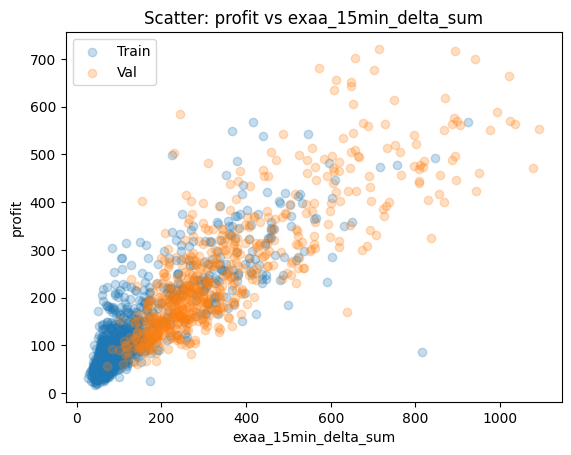

/var/folders/83/hxkk8qrs62xfzh1l_vbb4grc0000gn/T/ipykernel_94010/509874627.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = tmp.groupby("bin").agg(


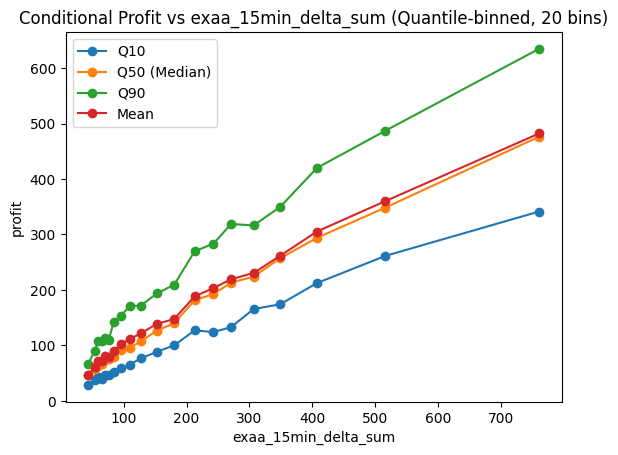

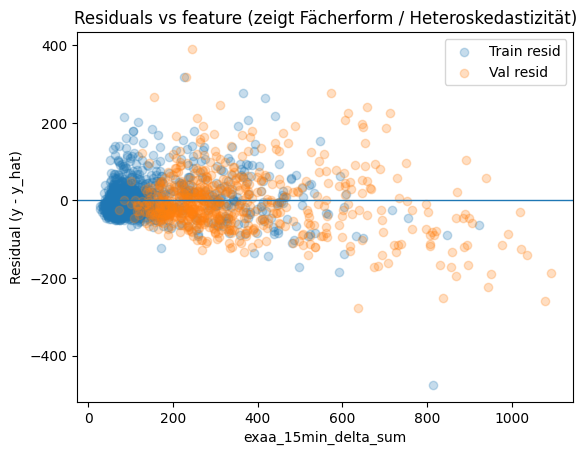

=== LinearRegression with 1 feature ===
Train R2: 0.7079889464812842
Val   R2: 0.673077732173631
Val  MAE: 56.658074077881274
Intercept: 36.16685876922122
Coef: 0.6446882741378277


In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_absolute_error

# ----------------------------
# 0) Setup: Train/Val Split (Time order)
# ----------------------------
target = "profit"
feature_1 = "exaa_15min_delta_sum"   # <- dein Hauptfeature

df = df_daily.copy()


q_std = df["exaa_15min_de_lu_eur_per_mwh_std"].quantile(0.99)
q_profit = df["profit"].quantile(0.99)

df = df[
    (df["exaa_15min_de_lu_eur_per_mwh_std"] <= q_std) &
    (df["profit"] <= q_profit)
]


# optional: drop rows with NaNs in used columns
df = df.dropna(subset=[target, feature_1]).reset_index(drop=True)

n = len(df)
split = int(n * 0.65)

train_df = df.iloc[:split].copy()
val_df   = df.iloc[split:].copy()

x_train = train_df[feature_1].values.reshape(-1, 1)
y_train = train_df[target].values
x_val   = val_df[feature_1].values.reshape(-1, 1)
y_val   = val_df[target].values

# ----------------------------
# 1) Plot A: Scatter (Train + Val)
# ----------------------------
plt.figure()
plt.scatter(train_df[feature_1], train_df[target], alpha=0.25, label="Train")
plt.scatter(val_df[feature_1],   val_df[target],   alpha=0.25, label="Val")
plt.xlabel(feature_1)
plt.ylabel(target)
plt.title(f"Scatter: {target} vs {feature_1}")
plt.legend()
plt.show()

# ----------------------------
# 2) Plot B: Binned conditional distribution (Quantiles per bin)
#    -> zeigt dir direkt: Var(profit | std) und ob es "Fächerform" gibt
# ----------------------------
# Wir bauen Bins nach Quantilen von feature_1 (auf Gesamtmenge oder nur Train)
num_bins = 20
bins = pd.qcut(df[feature_1], q=num_bins, duplicates="drop")

tmp = df[[feature_1, target]].copy()
tmp["bin"] = bins

# pro Bin: Feature-Mittelwert + Profit-Quantile
summary = tmp.groupby("bin").agg(
    x_mean=(feature_1, "mean"),
    y_q10=(target, lambda s: np.quantile(s, 0.10)),
    y_q50=(target, lambda s: np.quantile(s, 0.50)),
    y_q90=(target, lambda s: np.quantile(s, 0.90)),
    y_mean=(target, "mean"),
    count=(target, "size"),
).reset_index(drop=True)

plt.figure()
plt.plot(summary["x_mean"], summary["y_q10"], marker="o", label="Q10")
plt.plot(summary["x_mean"], summary["y_q50"], marker="o", label="Q50 (Median)")
plt.plot(summary["x_mean"], summary["y_q90"], marker="o", label="Q90")
plt.plot(summary["x_mean"], summary["y_mean"], marker="o", label="Mean")
plt.xlabel(feature_1)
plt.ylabel(target)
plt.title(f"Conditional Profit vs {feature_1} (Quantile-binned, {num_bins} bins)")
plt.legend()
plt.show()

# ----------------------------
# 3) Plot C: Residuals vs feature_1 (für Heteroskedastizität)
# ----------------------------
lin = LinearRegression()
lin.fit(x_train, y_train)

y_train_pred = lin.predict(x_train)
y_val_pred   = lin.predict(x_val)

train_resid = y_train - y_train_pred
val_resid   = y_val - y_val_pred

plt.figure()
plt.scatter(train_df[feature_1], train_resid, alpha=0.25, label="Train resid")
plt.scatter(val_df[feature_1],   val_resid,   alpha=0.25, label="Val resid")
plt.axhline(0, linewidth=1)
plt.xlabel(feature_1)
plt.ylabel("Residual (y - y_hat)")
plt.title("Residuals vs feature (zeigt Fächerform / Heteroskedastizität)")
plt.legend()
plt.show()

# ----------------------------
# 4) Linear Regression Test (1 Feature)
# ----------------------------
print("=== LinearRegression with 1 feature ===")
print("Train R2:", r2_score(y_train, y_train_pred))
print("Val   R2:", r2_score(y_val, y_val_pred))
print("Val  MAE:", mean_absolute_error(y_val, y_val_pred))
print("Intercept:", lin.intercept_)
print("Coef:", lin.coef_[0])

# ----------------------------
# 5) Optional: multivariate linear model (alle Features außer profit/cycles)
#    -> Achtung: nur w



In [73]:
"""

import pandas as pd
from pathlib import Path

in_path = Path("data/exaa_h_prices/AuctionData_2025-12-15.xlsx")
out_path = in_path.with_suffix(".csv")

df = pd.read_excel(
    in_path,
    dtype={"GREY_DE_price": str}
)

# Hour für Sortierung
df["ProductHour"] = df["Product"].str.extract(r"H(\d{1,2})", expand=False).astype(int)

# DeliveryDay normalize: aus allem was da steht ein sortierbares YYYYMMDD bauen
# Beispiele:
# "01.01.2019" -> 20190101
# "2019-01-13 00:00:00" -> 20190113
s = df["DeliveryDay"].astype(str)

# Fall 1: ISO-like "YYYY-MM-DD ..."
iso = s.str.extract(r"(\d{4})-(\d{2})-(\d{2})", expand=True)
# Fall 2: DE-like "DD.MM.YYYY"
de = s.str.extract(r"(\d{2})\.(\d{2})\.(\d{4})", expand=True)

# Baue sort key: bevorzugt ISO, sonst DE
sortkey = pd.Series(index=df.index, dtype="string")
sortkey_iso = iso[0] + iso[1] + iso[2]          # YYYYMMDD
sortkey_de  = de[2]  + de[1]  + de[0]           # YYYYMMDD

sortkey = sortkey_iso
sortkey = sortkey.where(sortkey.notna(), sortkey_de)

# Wenn hier noch NaNs sind, sind da wirklich “komische” Werte drin:
if sortkey.isna().any():
    bad = df.loc[sortkey.isna(), "DeliveryDay"].head(10).tolist()
    raise ValueError(f"Kann DeliveryDay nicht normalisieren, Beispiele: {bad}")

df["DeliveryDay_sortkey"] = sortkey

# Sortieren + neu indexieren
df = df.sort_values(["DeliveryDay_sortkey", "ProductHour"]).reset_index(drop=True)

# Preis robust fixen (funktioniert für "13,54" UND "13.54" UND "20" usw.)
s = df["GREY_DE_price"].astype(str).str.strip()

# optional: komische Spaces entfernen (NBSP kommt gern aus Excel)
s = s.str.replace("\u00a0", "", regex=False).str.replace(" ", "", regex=False)

mask_comma = s.str.contains(",", na=False)

# Nur bei Komma: Tausenderpunkte entfernen und Komma -> Punkt
s.loc[mask_comma] = (
    s.loc[mask_comma]
      .str.replace(".", "", regex=False)
      .str.replace(",", ".", regex=False)
)

# Bei den übrigen (ohne Komma) NICHT die Punkte entfernen – das sind Dezimalpunkte oder gar keine
df["GREY_DE_price"] = pd.to_numeric(s, errors="raise")

# Stündlichen Index erzeugen
start_utc = pd.Timestamp("2018-12-31 23:00:00")
df["timestamp_utc"] = start_utc + pd.to_timedelta(df.index, unit="h")
df = df.set_index("timestamp_utc")
df.index.name = "timestamp_utc"

# Checks: Ende + Lücken
expected_end = start_utc + pd.Timedelta(hours=len(df) - 1)
if df.index[-1] != expected_end:
    raise ValueError(f"Ende passt nicht: erwartet {expected_end}, ist {df.index[-1]}")
if not df.index.equals(pd.date_range(start_utc, periods=len(df), freq="h")):
    raise ValueError("Index ist nicht exakt stündlich ohne Lücken.")

# Cleanup + Export
df = df.drop(columns=["DeliveryDay_sortkey", "ProductHour"], errors="ignore")
df.to_csv(
    out_path,
    sep=",",          # Komma als Spaltentrenner
    index=True,       # Zeitstempel bleibt in der CSV
    encoding="utf-8"
)
print(f"Gespeichert: {out_path}")


"""

'\n\nimport pandas as pd\nfrom pathlib import Path\n\nin_path = Path("data/exaa_h_prices/AuctionData_2025-12-15.xlsx")\nout_path = in_path.with_suffix(".csv")\n\ndf = pd.read_excel(\n    in_path,\n    dtype={"GREY_DE_price": str}\n)\n\n# Hour für Sortierung\ndf["ProductHour"] = df["Product"].str.extract(r"H(\\d{1,2})", expand=False).astype(int)\n\n# DeliveryDay normalize: aus allem was da steht ein sortierbares YYYYMMDD bauen\n# Beispiele:\n# "01.01.2019" -> 20190101\n# "2019-01-13 00:00:00" -> 20190113\ns = df["DeliveryDay"].astype(str)\n\n# Fall 1: ISO-like "YYYY-MM-DD ..."\niso = s.str.extract(r"(\\d{4})-(\\d{2})-(\\d{2})", expand=True)\n# Fall 2: DE-like "DD.MM.YYYY"\nde = s.str.extract(r"(\\d{2})\\.(\\d{2})\\.(\\d{4})", expand=True)\n\n# Baue sort key: bevorzugt ISO, sonst DE\nsortkey = pd.Series(index=df.index, dtype="string")\nsortkey_iso = iso[0] + iso[1] + iso[2]          # YYYYMMDD\nsortkey_de  = de[2]  + de[1]  + de[0]           # YYYYMMDD\n\nsortkey = sortkey_iso\nsortkey =